In [1]:
print("hello")

hello


In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]





In [4]:
# graph_builder

In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")


In [7]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7837b54e9520>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7837b524d610>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
# # llm = init_chat_model("groq:llama-3.1-8b-instant")
llm = init_chat_model("groq:llama-3.1-8b-instant")
# llm

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     model="gpt-4o-mini",
#     temperature=0
# )

In [9]:
#Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

In [10]:
graph_builder = StateGraph(State)
##adding nodes
graph_builder.add_node("llmchatbot",chatbot)

##adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

##compile the graph 
graph = graph_builder.compile()

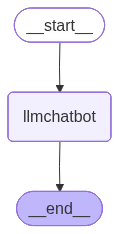

In [11]:
## visualize the graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
response = graph.invoke({"messages":"hi"})
response['messages'][-1].content

'How can I assist you today?'

In [13]:
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value['messages'][-1].content)

I'm just a computer program, so I don't have feelings, but I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?


###chat bot with tools

In [14]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'response_time': 0.67,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. LangGraph illuminates the processes within an AI workflow, allowing full transparency of the agent’s state. By combining these technologies with a set of APIs and tools, LangGraph provides users with a versatile platform for developing AI solutions and workflows including chatbots, state graphs and other agent-based systems. **Nodes**: In LangGraph, nodes represent individual components or agents within an AI workflow. LangGraph uses enhanced decisio

In [29]:
def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [30]:
tools=[tool,multiply]

In [31]:
llm_with_tools = llm.bind_tools(tools)

In [32]:
display(llm_with_tools)

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7837b53dde20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7837b524e9f0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a

### state graph

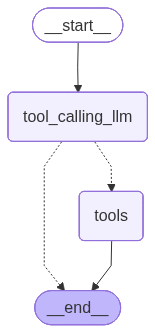

In [33]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination 

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools",END)


#compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response = graph.invoke({"messages":"what is the recent ai news"})

In [35]:
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fintechfutures.com/ai-in-fintech/february-2026-top-five-ai-stories-of-the-month", "title": "February 2026: Top five AI stories of the month - FinTech Futures", "score": 0.7040996, "published_date": "Fri, 27 Feb 2026 13:39:29 GMT", "content": "## BridgeWise acquires Context Analytics for new pAI agent\\n\\nUS fintech BridgeWise has purchased Context Analytics, a data processing firm based in Chicago, for an undisclosed sum. Plans to merge the two companies will provide \\"a level of asset analysis completeness that stands alone in the industry\\", according to BridgeWise.\\n\\nThrough its latest acquisition, BridgeWise claims to be \\"uniquely capable of decoding the full spectrum of market information\\", with the joint technology to serve as \\"a catalyst for launching pAI\\".\\n\\npAI is a new AI wealth agent that BridgeWise says \\"builds, reviews, and optimises i

In [36]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (z2rpzrdky)
 Call ID: z2rpzrdky
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
  tavily_search (gvk3vphts)
 Call ID: gvk3vphts
  Args:
    query: AI news updates
    search_depth: advanced
    topic: news
  tavily_search (4kv2mjysc)
 Call ID: 4kv2mjysc
  Args:
    query: latest AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/viviantoh/2026/02/24/china-startups-is-driving-the-future-of-global-robotaxi-deployment/", "title": "China AI Companies Drive The Future Of Global Robotaxi Deployment - Forbes", "scor

In [37]:
m_response = graph.invoke({"messages":"what is 2 multiplied by 3"})

In [38]:
for m in m_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (bb3aaxq3s)
 Call ID: bb3aaxq3s
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


### React Archi

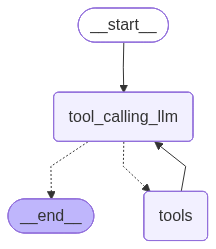

In [39]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination 

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")


#compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
m_response = graph.invoke({"messages":"give me the lates ai news and then multiply 4 and 5"})

for m in m_response['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the lates ai news and then multiply 4 and 5
================================== Ai Message ==================================
Tool Calls:
  tavily_search (3vs60artk)
 Call ID: 3vs60artk
  Args:
    query: latest AI news
    time_range: day
    topic: news
  multiply (j651v0w1y)
 Call ID: j651v0w1y
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.lightreading.com/ai-machine-learning/intel-discusses-ai-5g-innovation-and-the-road-to-6g", "title": "Intel Discusses AI, 5G Innovation and the Road to 6G - Light Reading", "score": 0.8688268, "published_date": "Tue, 03 Mar 2026 17:14:08 GMT", "content": "# Intel Discusses AI, 5G Innovation and the Road to 6G. Intel’s vice president and general manager of Network

### Adding a memory in Agentic graph

In [44]:
m_response = graph.invoke({"messages":"Hello my name is saif"})

for m in m_response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is saif
================================== Ai Message ==================================

Hello Saif, how can I assist you today?


In [45]:
m_response = graph.invoke({"messages":"what is my name ?"})

for m in m_response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I don't know your name. This function doesn't seem to be a function in the given tools.


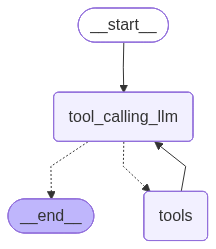

In [51]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

## node defination 
memory = MemorySaver()

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

##Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools","tool_calling_llm")


#compile the graph
graph = builder.compile(checkpointer=memory)



display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages":"Hii my name is saif"},config=config)

response

{'messages': [HumanMessage(content='Hii my name is saif', additional_kwargs={}, response_metadata={}, id='86cf5d4c-6bdf-4195-81f2-369e0837a1d0'),
  AIMessage(content="It's nice to meet you, Saif. Is there something I can help you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1752, 'total_tokens': 1772, 'completion_time': 0.035444773, 'completion_tokens_details': None, 'prompt_time': 0.170564002, 'prompt_tokens_details': None, 'queue_time': 0.057798618, 'total_time': 0.206008775}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb5c1-3b1e-7a93-a5b4-4e0a39f6117d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 20, 'total_tokens': 1772})]}

In [53]:
response['messages'][-1].content

"It's nice to meet you, Saif. Is there something I can help you with?"

In [56]:
response = graph.invoke({"messages":"Hii do you remember my name ?"},config=config)

response

{'messages': [HumanMessage(content='Hii my name is saif', additional_kwargs={}, response_metadata={}, id='86cf5d4c-6bdf-4195-81f2-369e0837a1d0'),
  AIMessage(content="It's nice to meet you, Saif. Is there something I can help you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1752, 'total_tokens': 1772, 'completion_time': 0.035444773, 'completion_tokens_details': None, 'prompt_time': 0.170564002, 'prompt_tokens_details': None, 'queue_time': 0.057798618, 'total_time': 0.206008775}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb5c1-3b1e-7a93-a5b4-4e0a39f6117d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 20, 'total_tokens': 1772}),
  HumanMessage(content='Hii what is my name ?', additional_kwargs={}, response_metadata={}, id='9d061e51

In [57]:
response['messages'][-1].content

'Yes, I remember your name is Saif.'

In [58]:
from langgraph.checkpoint.memory import MemorySaver

## node defination 
memory = MemorySaver()

In [59]:
def superbot(state:State):
    return {"message":[llm.invoke(state['messages'])]}

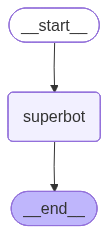

In [68]:
graph=StateGraph(State)

graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [66]:
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages":"Hello my name is saif"},config=config)

{'messages': [HumanMessage(content='Hello my name is saif', additional_kwargs={}, response_metadata={}, id='774e525c-8cef-4b5b-871f-2ba8338d9021'),
  HumanMessage(content='Hello my name is saif', additional_kwargs={}, response_metadata={}, id='c41e2bd7-4613-41ea-a9c0-1cba5860898d')]}

In [69]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream(
    {"messages": "Hi, My name is saif And I like football"},
    config,
    stream_mode="updates"
):
    print(chunk)

{'superbot': None}
